In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
# Some ploting setup
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
fonttitle=18
fontlabel=12
savefig=True

In [32]:
with np.load('../specfem2d_examples/homotop/data_specfem_homotop.npz') as data:
    vx_specfem = data['vx']
    vz_specfem = data['vz']
    dt_specfem = data['dt']
# with np.load('../specfem2d_examples/homotop/data_specfem_homotop_800.npz') as data:
#     vx_devito = data['vx']
#     vz_devito = data['vz']
#     dt_devito = data['dt']
with np.load('../devito_examples/homotop/data_devito_homotop.npz') as data:
    vx_devito = data['vx']
    vz_devito = data['vz']
    dt_devito = data['dt']

In [33]:
vx_specfem.max()

np.float64(0.015062173828482628)

In [34]:
np.abs(np.max(vx_specfem)), np.abs(np.max(vz_specfem))

(np.float64(0.015062173828482628), np.float64(0.03387952595949173))

In [35]:
# normalized trace by trace
mx = np.max(np.abs(vx_specfem), axis=0)
mz = np.max(np.abs(vz_specfem), axis=0)

mask_x = mx > 0
mask_z = mz > 0
vx_specfem *= -1/np.max(np.abs(vx_specfem))
vz_specfem *=  1/np.max(np.abs(vz_specfem))
# vx_specfem[:, mask_x] = -vx_specfem[:, mask_x] / mx[mask_x]
# vz_specfem[:, mask_z] =  vz_specfem[:, mask_z] / mz[mask_z]


# vx_devito = vx_devito / np.max(np.abs(vx_devito), axis=0)
# vz_devito = vz_devito / np.max(np.abs(vz_devito), axis=0)

In [36]:
time_specfem = np.arange(vx_specfem.shape[0]) * dt_specfem
time_devito = np.arange(vx_devito.shape[0]) * dt_devito * 1e-3  # Convert ms to s

# Use time specfem as reference
# Interpolate Devito data to Specfem time grid using scipy interp
from scipy.interpolate import interp1d

interp_vx = interp1d(time_devito, vx_devito, axis=0, kind='linear', bounds_error=False,fill_value=0.0)
interp_vz = interp1d(time_devito, vz_devito, axis=0, kind='linear', bounds_error=False, fill_value=0.0)
vx_devito_interp = interp_vx(time_specfem) 
vz_devito_interp = interp_vz(time_specfem) 
# Compute time shift in trace at 50m
from scipy.signal import correlate, correlation_lags
trace = 95
corrz = correlate(vz_devito_interp[:, trace], vz_specfem[:, trace], mode='full')
corrx = correlate(vx_devito_interp[:, trace], vx_specfem[:, trace], mode='full')
lagsx = correlation_lags(len(vx_devito_interp[:, trace]), len(vx_specfem[:, trace]), mode='full')  # misma longitud que corr
dtx = time_specfem[1] - time_specfem[0]
time_shiftx = lagsx[np.argmax(corrx)] * dtx
lagsz = correlation_lags(len(vz_devito_interp[:, trace]), len(vz_specfem[:, trace]), mode='full')  # misma longitud que corr
dtz = time_specfem[1] - time_specfem[0]
time_shiftz = lagsz[np.argmax(corrz)] * dtz
# time_shiftz = lagsz[np.argmax(corrz)] * dtz
time_shift = (time_shiftx + time_shiftz) / 2.0
print(f'Time shift between Devito and Analytic at trace {trace}: {time_shift:.4f} s')
# Apply time shift
time_specfem_shifted_x = time_specfem + time_shiftz
time_specfem_shifted_z = time_specfem + time_shiftz
vx_devito_interp = interp_vx(time_specfem_shifted_x) 
vz_devito_interp = interp_vz(time_specfem_shifted_z)
# Trace by trace amplitude correction with dot product (trace by trace)
amplitude_correction_x = np.sum(vx_specfem * vx_devito_interp, axis=0) / np.sum(vx_devito_interp * vx_devito_interp, axis=0)
amplitude_correction_z = np.sum(vz_specfem * vz_devito_interp, axis=0) / np.sum(vz_devito_interp * vz_devito_interp, axis=0)
vx_devito_interp = vx_devito_interp * amplitude_correction_x
vz_devito_interp = vz_devito_interp * amplitude_correction_z
# vx_devito_interp *= 0.3
# vz_devito_interp *= 0.3

Time shift between Devito and Analytic at trace 95: -0.0196 s


In [37]:
time_devito.size/time_specfem.size

1.7927012164639227

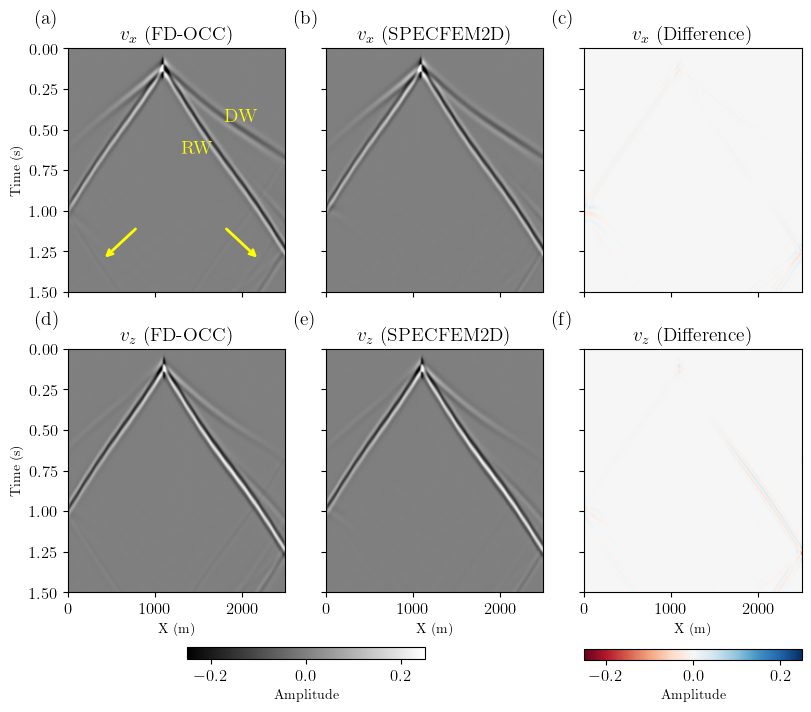

In [38]:
pcx=0.25
pcz=0.25
xmin=0
xmax=2500
from devitocurvilinear import odt_seismics
cmap = 'gray'
cmapdif = 'RdBu'
extent = [xmin, xmax, time_specfem[-1], time_specfem[0]]
fig1, ax = plt.subplots(2, 3, layout='constrained', sharey=True, sharex=True, figsize=(8,7))
# VX
ax[0,0].set_title('$v_x$ (FD-OCC)', fontsize=14)
imx1=ax[0,0].imshow(vx_devito_interp, cmap=cmap, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
ax[0,0].set_ylabel('Time (s)')
ax[0,1].set_title('$v_x$ (SPECFEM2D)', fontsize=14)
imx2=ax[0,1].imshow(vx_specfem, cmap=cmap, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
ax[0,2].set_title('$v_x$ (Difference)', fontsize=14)
imx3 = ax[0,2].imshow(vx_devito_interp - vx_specfem, cmap=cmapdif, vmin=-pcx, vmax=pcx, origin='upper', aspect='auto',
           extent=extent)
# VZ
ax[1,0].set_title('$v_z$ (FD-OCC)', fontsize=14)
imv1=ax[1,0].imshow(vz_devito_interp, cmap=cmap, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
ax[1,0].set_ylabel('Time (s)')
ax[1,0].set_xlabel('X (m)')
ax[1,1].set_title('$v_z$ (SPECFEM2D)', fontsize=14)
imv2=ax[1,1].imshow(vz_specfem, cmap=cmap, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
ax[1,1].set_xlabel('X (m)')
fig1.colorbar(imv2, ax=ax[1,:2], orientation='horizontal', pad=0.04, shrink=0.5, label='Amplitude')
ax[1,2].set_title('$v_z$ (Difference)', fontsize=14)
imv3 = ax[1,2].imshow(vz_devito_interp - vz_specfem, cmap=cmapdif, vmin=-pcz, vmax=pcz, origin='upper', aspect='auto',
           extent=extent)
fig1.colorbar(imv3, ax=ax[:,2], orientation='horizontal', pad=0.02, label='Amplitude')
ax[1,2].set_xlabel('X (m)')
axi = ax[0,0]
axi.text(1800, 0.45, 'DW', fontsize=14, color='yellow')
axi.text(1300, 0.65, 'RW', fontsize=14, color='yellow')
axi.annotate("", xy=(400, 1.3), xytext=(800, 1.1),arrowprops=dict(arrowstyle="->", color='yellow',lw=2))
axi.annotate("", xy=(2200, 1.3), xytext=(1800, 1.1),arrowprops=dict(arrowstyle="->", color='yellow',lw=2))

ax[0,0].text(-0.15, 1.1, '(a)', fontsize=14, transform=ax[0,0].transAxes)
ax[0,1].text(-0.15, 1.1, '(b)', fontsize=14, transform=ax[0,1].transAxes)
ax[0,2].text(-0.15, 1.1, '(c)', fontsize=14, transform=ax[0,2].transAxes)
ax[1,0].text(-0.15, 1.1, '(d)', fontsize=14, transform=ax[1,0].transAxes)
ax[1,1].text(-0.15, 1.1, '(e)', fontsize=14, transform=ax[1,1].transAxes)
ax[1,2].text(-0.15, 1.1, '(f)', fontsize=14, transform=ax[1,2].transAxes)

if savefig:
    fig1.savefig('homotop_shotgather_comparison.pdf', bbox_inches='tight', transparent=True)

In [39]:
norm_devito_vx = np.linalg.norm(vx_devito_interp)
norm_specfem_vx = np.linalg.norm(vx_specfem)
error_vx = np.linalg.norm(vx_devito_interp - vx_specfem)**2 / norm_specfem_vx**2
norm_devito_vz = np.linalg.norm(vz_devito_interp)
norm_specfem_vz = np.linalg.norm(vz_specfem)
error_vz = np.linalg.norm(vz_devito_interp - vz_specfem)**2 / norm_specfem_vz**2
print(f'Relative L2 error vx: {error_vx:.2%}')
print(f'Relative L2 error vz: {error_vz:.2%}')
# Correlation all the traces (entire shot gather)
correlation_x = np.sum(vx_specfem * vx_devito_interp) / (norm_specfem_vx * norm_devito_vx)
correlation_z = np.sum(vz_specfem * vz_devito_interp) / (norm_specfem_vz * norm_devito_vz)
print(f'Correlation vx: {correlation_x:.2%}')
print(f'Correlation vz: {correlation_z:.2%}')

Relative L2 error vx: 0.89%
Relative L2 error vz: 1.33%
Correlation vx: 99.55%
Correlation vz: 99.33%


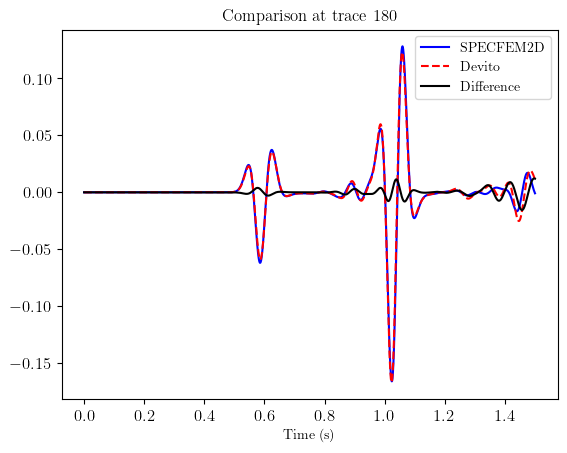

In [40]:
trace = 180
plt.plot(time_specfem, vx_specfem[:, trace], label='SPECFEM2D', color='blue')
plt.plot(time_specfem, vx_devito_interp[:, trace], label='Devito', color='red', linestyle='--')
plt.plot(time_specfem, vx_devito_interp[:, trace] - vx_specfem[:, trace], label='Difference', color='black', linestyle='-')
plt.xlabel('Time (s)')
plt.title(f'Comparison at trace {trace}')
plt.legend()
plt.show()

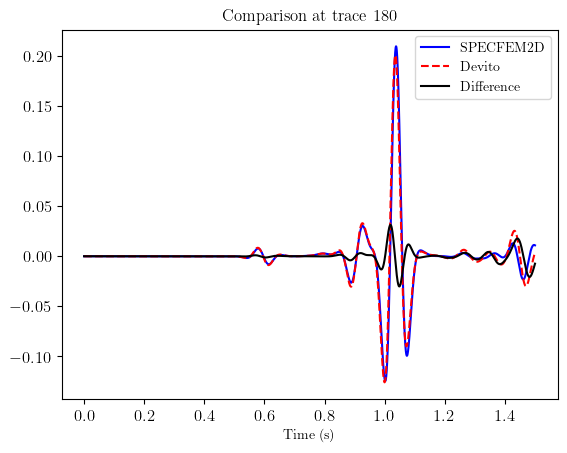

In [41]:
plt.plot(time_specfem, vz_specfem[:, trace], label='SPECFEM2D', color='blue')
plt.plot(time_specfem, vz_devito_interp[:, trace], label='Devito', color='red', linestyle='--')
plt.plot(time_specfem, vz_devito_interp[:, trace] - vz_specfem[:, trace], label='Difference', color='black', linestyle='-')
plt.xlabel('Time (s)')
plt.title(f'Comparison at trace {trace}')
plt.legend()
plt.show()

In [42]:
# L2 error in trace 100
l2_error_vx_trace = np.linalg.norm(vx_devito_interp[:, trace] - vx_specfem[:, trace])**2 / np.linalg.norm(vx_specfem[:, trace])**2
l2_error_vz_trace = np.linalg.norm(vz_devito_interp[:, trace] - vz_specfem[:, trace])**2 / np.linalg.norm(vz_specfem[:, trace])**2           
print(f'Relative L2 error vx at trace {trace}: {l2_error_vx_trace:.2%}')
print(f'Relative L2 error vz at trace {trace}: {l2_error_vz_trace:.2%}')

Relative L2 error vx at trace 180: 1.43%
Relative L2 error vz at trace 180: 3.85%


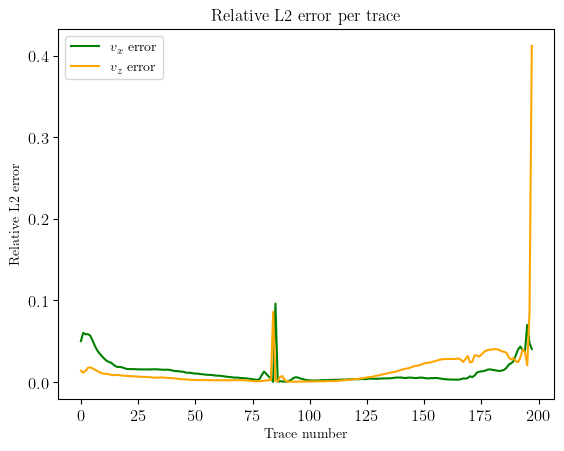

In [43]:
# L2 error per trace
l2_errors_vx = np.linalg.norm(vx_devito_interp - vx_specfem, axis=0)**2 / np.linalg.norm(vx_specfem, axis=0)**2
l2_errors_vz = np.linalg.norm(vz_devito_interp - vz_specfem, axis=0)**2 / np.linalg.norm(vz_specfem, axis=0)**2           
plt.plot(l2_errors_vx[3:], label='$v_x$ error', color='green')
plt.plot(l2_errors_vz[3:], label='$v_z$ error', color='orange')
plt.xlabel('Trace number')
plt.ylabel('Relative L2 error')
plt.title('Relative L2 error per trace')
plt.legend()

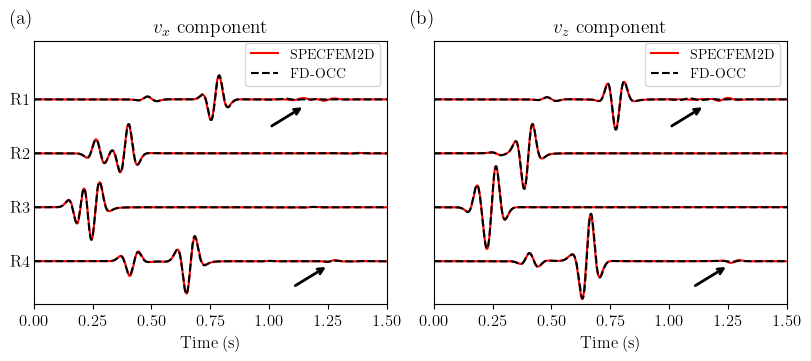

In [44]:
fig, ax = plt.subplots(1, 2, layout='constrained', sharey=True, figsize=(8, 3.5))
vstep=0.25
vbias=vstep*1.1
bias=0.0
for trace in [20,60,100,140]:
    bias -=  vstep  # for better visualization
    ax[0].plot(time_specfem, vx_devito_interp[:, trace] + bias, label='Devito', color='red', linestyle='-')
    ax[0].plot(time_specfem, vx_specfem[:, trace] + bias, label='Specfem', color='black', linestyle='--')
    ax[1].plot(time_specfem, vz_devito_interp[:, trace] + bias, label='Devito', color='red', linestyle='-')
    ax[1].plot(time_specfem, vz_specfem[:, trace] + bias, label='Specfem', color='black', linestyle='--')


ax[0].set_title('$v_x$ component', fontsize=14)
ax[1].set_title('$v_z$ component', fontsize=14)
ax[0].set_xlim(0, 1.5)
ax[0].set_ylim(-vstep*4.8, 0.02)
ax[1].set_xlim(0, 1.5)
ax[0].legend(['SPECFEM2D', 'FD-OCC'], fontsize=10, loc='upper right', bbox_to_anchor=(1, 1.02))
ax[1].legend(['SPECFEM2D', 'FD-OCC'], fontsize=10, loc='upper right', bbox_to_anchor=(1, 1.02))
ax[0].set_xlabel('Time (s)', fontsize=12)
ax[1].set_xlabel('Time (s)', fontsize=12)
ax[0].text(-0.1, -vbias, 'R1', fontsize=12)
ax[0].text(-0.1, -vbias-vstep, 'R2', fontsize=12)
ax[0].text(-0.1, -vbias-2*vstep, 'R3', fontsize=12)
ax[0].text(-0.1, -vbias-3*vstep, 'R4', fontsize=12)
ax[0].text(-0.1, 0.1, '(a)', fontsize=14)
ax[1].text(-0.1, 0.1, '(b)', fontsize=14)
ax[0].set_yticks([])

ax[0].annotate("", xy=(1.15, -0.28), xytext=(1.0, -0.38),arrowprops=dict(arrowstyle="->", color='black',lw=2))
ax[1].annotate("", xy=(1.15, -0.28), xytext=(1.0, -0.38),arrowprops=dict(arrowstyle="->", color='black',lw=2))
ax[0].annotate("", xy=(1.25, -1.02), xytext=(1.1, -1.12),arrowprops=dict(arrowstyle="->", color='black',lw=2))
ax[1].annotate("", xy=(1.25, -1.02), xytext=(1.1, -1.12),arrowprops=dict(arrowstyle="->", color='black',lw=2))
if savefig:
    fig.savefig('homotop_traces_comparison.pdf', bbox_inches='tight', transparent=True)

In [45]:
# L2 error in trace 100
for trace in [20,60,100,140]:
    vx_devito_trace = vx_devito_interp[:, trace]
    vz_devito_trace = vz_devito_interp[:, trace]

    # L2 relative error
    error_vx = np.linalg.norm(vx_devito_trace - vx_specfem[:, trace]) / np.linalg.norm(vx_specfem[:, trace])
    error_vz = np.linalg.norm(vz_devito_trace - vz_specfem[:, trace]) / np.linalg.norm(vz_specfem[:, trace])        
    # L2 (squared) relative error
    error_vx_2 = np.linalg.norm(vx_devito_trace - vx_specfem[:, trace])**2 / np.linalg.norm(vx_specfem[:, trace])**2
    error_vz_2 = np.linalg.norm(vz_devito_trace - vz_specfem[:, trace])**2 / np.linalg.norm(vz_specfem[:, trace])**2     
    # Correlation measure
    corr_vx = np.inner(vx_specfem[:, trace], vx_devito_trace) / (np.linalg.norm(vx_specfem[:, trace]) * np.linalg.norm(vx_devito_trace))
    corr_vz = np.inner(vz_specfem[:, trace], vz_devito_trace) / (np.linalg.norm(vz_specfem[:, trace]) * np.linalg.norm(vz_devito_trace))
    print(f'Correlation at trace {trace}:')  
    print(f'Correlation vx : {corr_vx:.2%}')
    print(f'Correlation vz : {corr_vz:.2%}')  

    print(f'L2 Relative Error at trace {trace}:')  
    print(f'Relative L2 (squared) error vx : {error_vx_2:.2%}')
    print(f'Relative L2 (squared) error vz : {error_vz_2:.2%}')

Correlation at trace 20:
Correlation vx : 99.07%
Correlation vz : 99.59%
L2 Relative Error at trace 20:
Relative L2 (squared) error vx : 1.85%
Relative L2 (squared) error vz : 0.82%
Correlation at trace 60:
Correlation vx : 99.56%
Correlation vz : 99.89%
L2 Relative Error at trace 60:
Relative L2 (squared) error vx : 0.87%
Relative L2 (squared) error vz : 0.21%
Correlation at trace 100:
Correlation vx : 99.83%
Correlation vz : 99.97%
L2 Relative Error at trace 100:
Relative L2 (squared) error vx : 0.34%
Relative L2 (squared) error vz : 0.05%
Correlation at trace 140:
Correlation vx : 99.74%
Correlation vz : 99.38%
L2 Relative Error at trace 140:
Relative L2 (squared) error vx : 0.52%
Relative L2 (squared) error vz : 1.23%
